# Chapter 14 — Monitoring, Drift, and Model Maintenance

This notebook is **self-contained**: it regenerates the LightGBM bundle and the 200-request log (with covariate drift at request 100) so it runs independently of Chapters 12 and 13. It then implements PSI and KS drift detection, rolling performance monitoring, and the drift response decision framework.

## Setup: Imports, Data, Model, and Log

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import uuid
import time
import warnings
import joblib
from pathlib import Path
from scipy.stats import ks_2samp
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import sys
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED, MODELS

sns.set_theme(style='whitegrid', palette='muted')
rng = np.random.default_rng(RANDOM_SEED)

MODELS.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)


In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pydantic import BaseModel, Field, ValidationError
import lightgbm as lgb

data = load_breast_cancer()
X_all = pd.DataFrame(data.data, columns=data.feature_names)
y_all = pd.Series(data.target, name='malignant')

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20,
    stratify=y_all, random_state=RANDOM_SEED
)

# ── Train LightGBM bundle ─────────────────────────────────────────────────
scaler_lgb = StandardScaler()
X_tr_sc = scaler_lgb.fit_transform(X_train)
X_te_sc = scaler_lgb.transform(X_test)

lgb_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05,
    num_leaves=31, random_state=RANDOM_SEED,
    n_jobs=-1, verbose=-1
)
lgb_model.fit(X_tr_sc, y_train)

auc = roc_auc_score(y_test, lgb_model.predict_proba(X_te_sc)[:, 1])
print(f'LightGBM ROC-AUC : {auc:.4f}')

lgb_bundle = {
    'model':         lgb_model,
    'scaler':        scaler_lgb,
    'feature_names': list(X_train.columns),
    'trained_at':    pd.Timestamp.now().isoformat(),
    'train_roc_auc': round(auc, 4),
}
lgb_path = MODELS / 'lightgbm_bundle.joblib'
joblib.dump(lgb_bundle, lgb_path, compress=3)
print(f'Bundle saved     : {lgb_path}')


LightGBM ROC-AUC : 0.9904
Bundle saved     : F:\project-workspace\quarto-book\data-mode-book\data-model-code\models\lightgbm_bundle.joblib


In [3]:
# ── Inline schemas and serving layer (self-contained) ─────────────────────
class CancerFeatures(BaseModel):
    mean_radius: float = Field(..., ge=0)
    mean_texture: float = Field(..., ge=0)
    mean_perimeter: float = Field(..., ge=0)
    mean_area: float = Field(..., ge=0)
    mean_smoothness: float = Field(..., ge=0)
    mean_compactness: float = Field(..., ge=0)
    mean_concavity: float = Field(..., ge=0)
    mean_concave_points: float = Field(..., ge=0)
    mean_symmetry: float = Field(..., ge=0)
    mean_fractal_dimension: float = Field(..., ge=0)
    radius_error: float = Field(..., ge=0)
    texture_error: float = Field(..., ge=0)
    perimeter_error: float = Field(..., ge=0)
    area_error: float = Field(..., ge=0)
    smoothness_error: float = Field(..., ge=0)
    compactness_error: float = Field(..., ge=0)
    concavity_error: float = Field(..., ge=0)
    concave_points_error: float = Field(..., ge=0)
    symmetry_error: float = Field(..., ge=0)
    fractal_dimension_error: float = Field(..., ge=0)
    worst_radius: float = Field(..., ge=0)
    worst_texture: float = Field(..., ge=0)
    worst_perimeter: float = Field(..., ge=0)
    worst_area: float = Field(..., ge=0)
    worst_smoothness: float = Field(..., ge=0)
    worst_compactness: float = Field(..., ge=0)
    worst_concavity: float = Field(..., ge=0)
    worst_concave_points: float = Field(..., ge=0)
    worst_symmetry: float = Field(..., ge=0)
    worst_fractal_dimension: float = Field(..., ge=0)

_model_state: dict = {}
FEATURE_MAP = {col.replace(' ', '_'): col for col in data.feature_names}

bundle = joblib.load(lgb_path)
_model_state.update({
    'model':         bundle['model'],
    'scaler':        bundle['scaler'],
    'feature_names': bundle['feature_names'],
    'model_name':    'lightgbm_bundle',
    'model_version': '1.0.0',
})

def _run_inference(features: CancerFeatures) -> tuple:
    feat_dict = features.model_dump()
    row  = {FEATURE_MAP[k]: v for k, v in feat_dict.items() if k in FEATURE_MAP}
    X_df = pd.DataFrame([row])[_model_state['feature_names']]
    X_sc = _model_state['scaler'].transform(X_df)
    prob = float(_model_state['model'].predict_proba(X_sc)[0, 1])
    return int(prob >= 0.5), prob

print('Serving layer initialised  ✓')


Serving layer initialised  ✓


### Generate 200-Request Log

Requests 0–99 are in-distribution; requests 100–199 inject covariate shift.

In [4]:
LOG_PATH = DATA_PROCESSED / 'api_request_log.jsonl'
LOG_PATH.unlink(missing_ok=True)
all_true_labels = []

for i in range(200):
    idx = i % len(X_test)
    row = X_test.iloc[idx].copy()
    if i >= 100:
        row['mean radius']  *= 1.4
        row['mean area']    *= 1.4
        row['worst radius'] *= 1.3

    true_label = int(y_test.iloc[idx])
    feat_dict  = {col.replace(' ', '_'): float(v) for col, v in row.items()}
    features_obj = CancerFeatures(**feat_dict)
    pred, prob   = _run_inference(features_obj)
    latency_ms   = float(rng.uniform(0.7, 3.2))
    request_id   = str(uuid.uuid4())[:8]

    record = {
        'request_id':    request_id,
        'timestamp':     pd.Timestamp.now().isoformat(),
        'features':      feat_dict,
        'prediction':    pred,
        'probability':   round(prob, 6),
        'latency_ms':    round(latency_ms, 3),
        'model_version': '1.0.0',
        'true_label':    true_label,
    }
    with open(LOG_PATH, 'a') as f:
        f.write(json.dumps(record) + '\n')
    all_true_labels.append(true_label)

log_records = [json.loads(l) for l in LOG_PATH.read_text().strip().split('\n')]
log_df = pd.DataFrame(log_records)
log_df['timestamp'] = pd.to_datetime(log_df['timestamp'])

print(f'Log written : {LOG_PATH}')
print(f'Records     : {len(log_df)}  (first 100 in-dist, next 100 drifted)')


Log written : F:\project-workspace\quarto-book\data-mode-book\data-model-code\data\processed\api_request_log.jsonl
Records     : 200  (first 100 in-dist, next 100 drifted)


## Monitoring Data Drift

### Population Stability Index

PSI quantifies how much the distribution of a feature has shifted between a reference (training) period and a production window:

$$\text{PSI} = \sum_{b=1}^{B}(p^\text{prod}_b - p^\text{ref}_b)\ln\frac{p^\text{prod}_b}{p^\text{ref}_b}$$

| PSI | Interpretation |
|---|---|
| < 0.10 | Negligible shift — no action |
| 0.10 – 0.20 | Moderate — investigate |
| ≥ 0.20 | Significant — prepare to retrain |

In [5]:
def compute_psi(reference: np.ndarray, production: np.ndarray,
                n_bins: int = 10) -> float:
    """Population Stability Index between reference and production arrays."""
    breakpoints = np.percentile(reference, np.linspace(0, 100, n_bins + 1))
    breakpoints[0]  -= 1e-8
    breakpoints[-1] += 1e-8
    ref_counts  = np.histogram(reference,  bins=breakpoints)[0]
    prod_counts = np.histogram(production, bins=breakpoints)[0]
    eps = 1e-6
    ref_pct  = (ref_counts  + eps) / (len(reference)  + eps * n_bins)
    prod_pct = (prod_counts + eps) / (len(production) + eps * n_bins)
    return float(np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct)))

print('compute_psi() defined  ✓')


compute_psi() defined  ✓


### Computing PSI and KS for All Features

In [6]:
# Reference: training data (rename spaces → underscores to match log)
ref_features = X_train.rename(columns={c: c.replace(' ', '_') for c in X_train.columns})
feature_names_api = list(ref_features.columns)

# Production windows from the log
prod_early = pd.DataFrame(log_df['features'].iloc[:100].tolist())
prod_late  = pd.DataFrame(log_df['features'].iloc[100:].tolist())

psi_results = []
for feat in feature_names_api:
    ref_vals   = ref_features[feat].values
    early_vals = prod_early[feat].values
    late_vals  = prod_late[feat].values

    psi_early = compute_psi(ref_vals, early_vals)
    psi_late  = compute_psi(ref_vals, late_vals)
    ks_stat, ks_pval = ks_2samp(ref_vals, late_vals)

    psi_results.append({
        'feature':   feat,
        'psi_early': psi_early,
        'psi_late':  psi_late,
        'ks_stat':   ks_stat,
        'ks_pval':   ks_pval,
        'drifted':   psi_late > 0.2 or ks_pval < 0.05,
    })

drift_df = pd.DataFrame(psi_results).sort_values('psi_late', ascending=False)

print(f'{"Feature":<32}  {"PSI early":>10}  {"PSI late":>9}  '
      f'{"KS stat":>8}  {"KS p-val":>9}  Drifted?')
print('─' * 87)
for _, row in drift_df.head(10).iterrows():
    flag = '⚠ YES' if row['drifted'] else '  no'
    print(f"  {row['feature']:<30}  {row['psi_early']:>10.4f}  "
          f"{row['psi_late']:>9.4f}  {row['ks_stat']:>8.4f}  "
          f"{row['ks_pval']:>9.4f}  {flag}")

n_drifted = drift_df['drifted'].sum()
print(f'\nFeatures flagged as drifted : {n_drifted} / {len(drift_df)}')


Feature                            PSI early   PSI late   KS stat   KS p-val  Drifted?
───────────────────────────────────────────────────────────────────────────────────────
  mean_radius                         0.0403     5.7572    0.5941     0.0000  ⚠ YES
  worst_radius                        0.1248     3.8587    0.4493     0.0000  ⚠ YES
  mean_area                           0.0328     2.0738    0.3600     0.0000  ⚠ YES
  worst_concave_points                0.2126     0.2107    0.1197     0.1744  ⚠ YES
  texture_error                       0.1837     0.1897    0.1335     0.0970    no
  worst_concavity                     0.1658     0.1491    0.0926     0.4519    no
  fractal_dimension_error             0.1354     0.1458    0.1122     0.2330    no
  worst_smoothness                    0.1864     0.1445    0.0779     0.6687    no
  mean_fractal_dimension              0.1127     0.1440    0.0890     0.5024    no
  worst_texture                       0.0827     0.1318    0.0914     0.46

### Visualising PSI by Feature

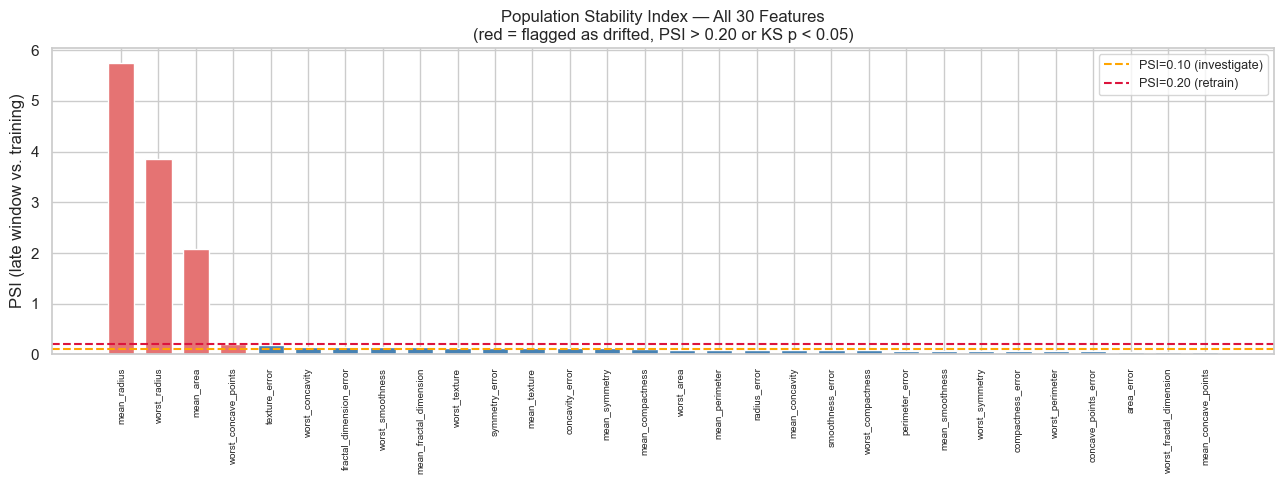

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(drift_df))
colors = ['#E57373' if d else 'steelblue' for d in drift_df['drifted']]
ax.bar(x, drift_df['psi_late'], color=colors, edgecolor='white', width=0.7)
ax.axhline(0.1, color='orange', lw=1.5, linestyle='--', label='PSI=0.10 (investigate)')
ax.axhline(0.2, color='crimson', lw=1.5, linestyle='--', label='PSI=0.20 (retrain)')
ax.set_xticks(x)
ax.set_xticklabels(drift_df['feature'], rotation=90, fontsize=7)
ax.set_ylabel('PSI (late window vs. training)')
ax.set_title('Population Stability Index — All 30 Features\n'
             '(red = flagged as drifted, PSI > 0.20 or KS p < 0.05)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'ch14_psi_all_features.png', dpi=150, bbox_inches='tight')
plt.show()


### Feature Distribution Shift — Top Drifted vs. Stable

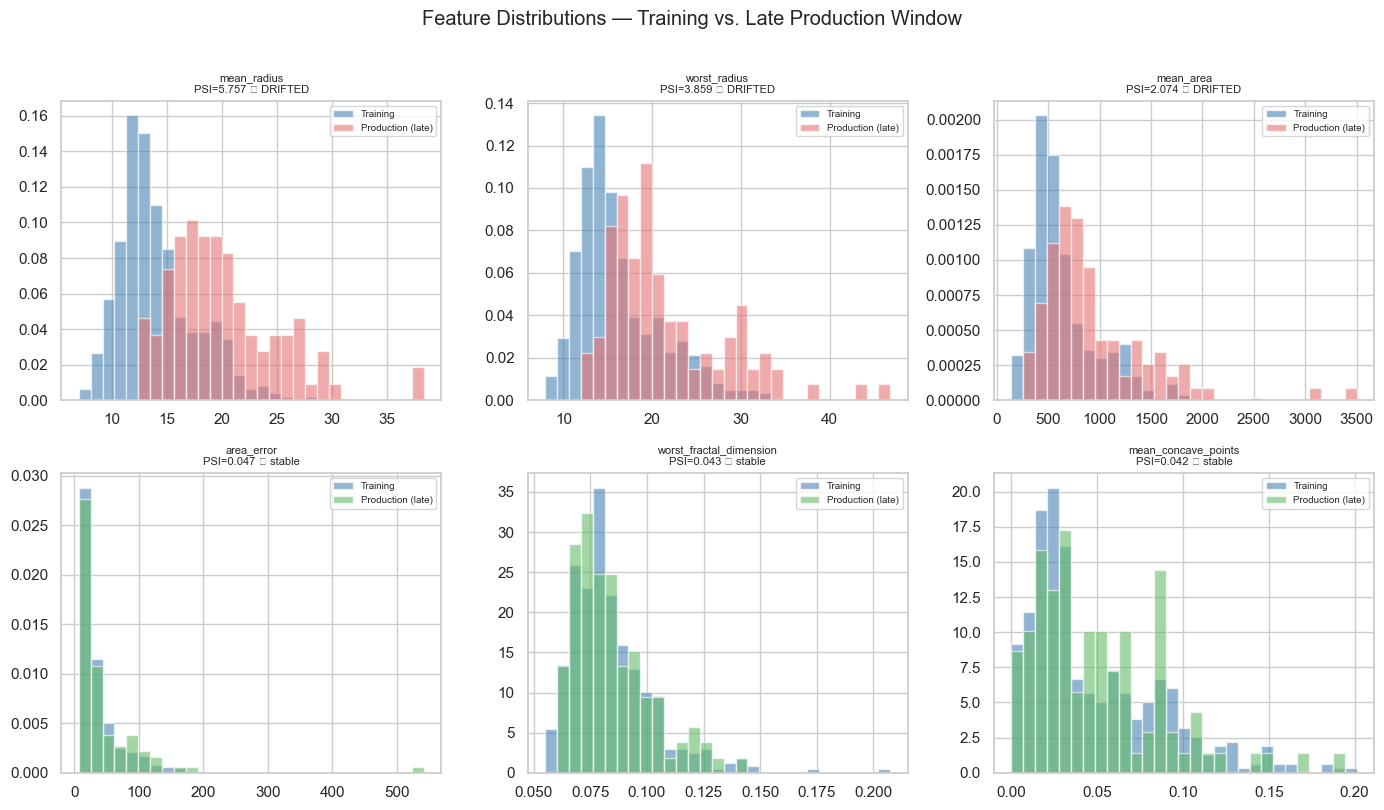

In [8]:
top_drift = drift_df[drift_df['drifted']].head(3)['feature'].tolist()
stable    = drift_df[~drift_df['drifted']].tail(3)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat, drifted in zip(axes.flatten(), top_drift + stable,
                              [True]*3 + [False]*3):
    ref_vals  = ref_features[feat].values
    late_vals = prod_late[feat].values
    bins = np.linspace(min(ref_vals.min(), late_vals.min()),
                       max(ref_vals.max(), late_vals.max()), 30)
    ax.hist(ref_vals,  bins=bins, alpha=0.6, color='steelblue',
            density=True, label='Training')
    ax.hist(late_vals, bins=bins, alpha=0.6,
            color='#E57373' if drifted else '#66BB6A',
            density=True, label='Production (late)')
    psi_val = drift_df.loc[drift_df['feature'] == feat, 'psi_late'].values[0]
    flag = ' ⚠ DRIFTED' if drifted else ' ✓ stable'
    ax.set_title(f'{feat}\nPSI={psi_val:.3f}{flag}', fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions — Training vs. Late Production Window', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'ch14_drift_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Monitoring Model Performance Drift

Rolling accuracy and F1 are computed over a sliding window of `W=20` requests. When ground-truth labels are available we can detect whether covariate shift is translating into real accuracy degradation.

In [9]:
WINDOW = 20
rolling_acc, rolling_f1, rolling_prob_mean, request_idx = [], [], [], []

for i in range(WINDOW, len(log_df) + 1):
    w        = log_df.iloc[i - WINDOW : i]
    y_true_w = w['true_label'].values
    y_pred_w = w['prediction'].values
    y_prob_w = w['probability'].values
    rolling_acc.append(accuracy_score(y_true_w, y_pred_w))
    rolling_f1.append(f1_score(y_true_w, y_pred_w, zero_division=0))
    rolling_prob_mean.append(y_prob_w.mean())
    request_idx.append(i)

pre_acc  = np.mean(rolling_acc[:80])
post_acc = np.mean(rolling_acc[-80:])
print(f'Mean rolling accuracy — pre-drift  : {pre_acc:.4f}')
print(f'Mean rolling accuracy — post-drift : {post_acc:.4f}')
print(f'Accuracy drop                       : {pre_acc - post_acc:.4f} '
      f'({(pre_acc - post_acc)/pre_acc*100:.1f}%)')


Mean rolling accuracy — pre-drift  : 0.9600
Mean rolling accuracy — post-drift : 0.9394
Accuracy drop                       : 0.0206 (2.1%)


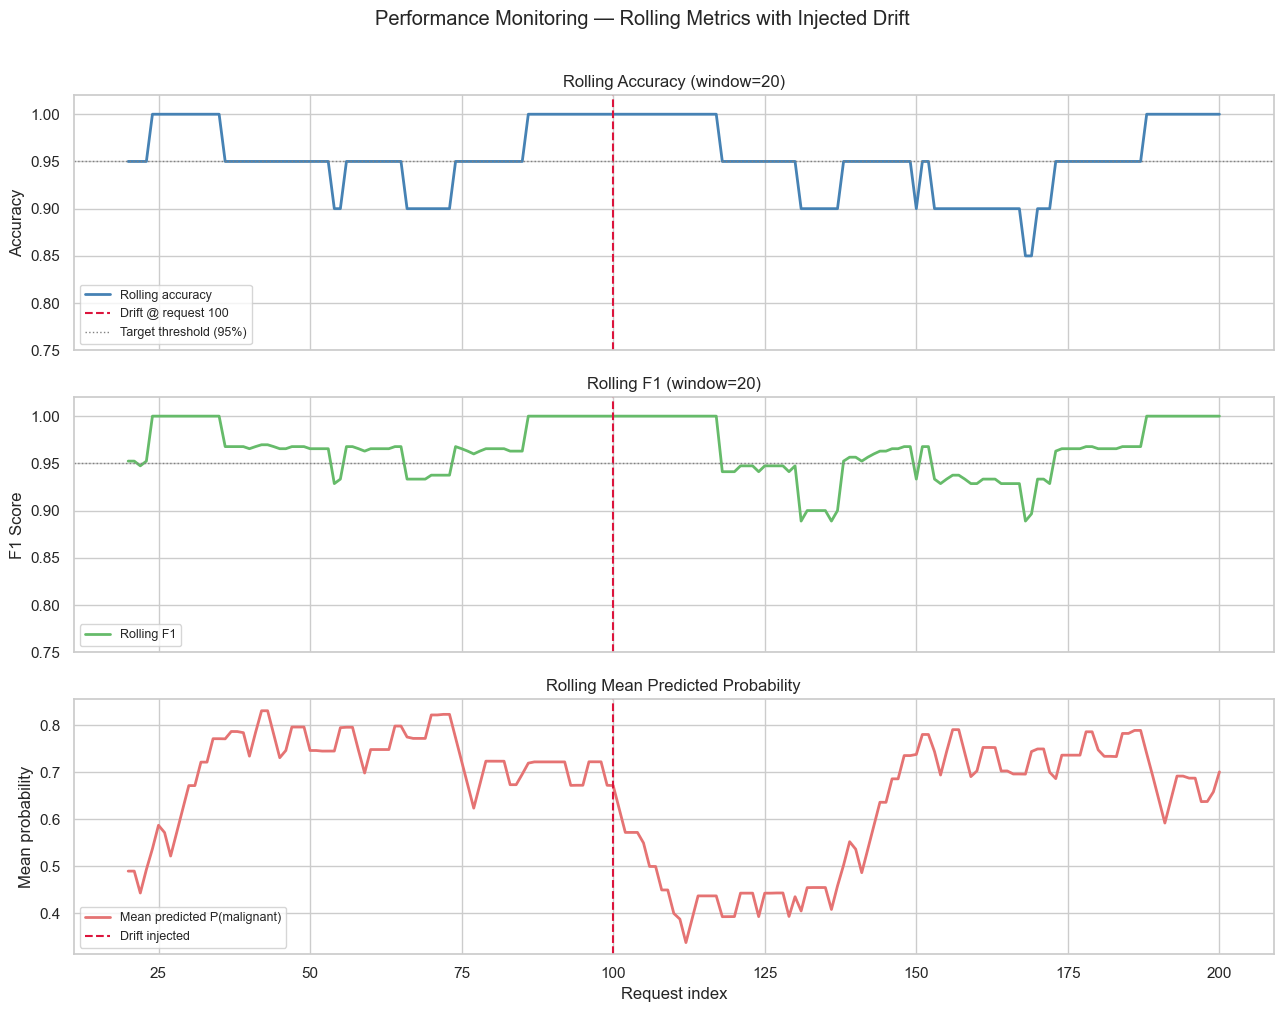

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
x = request_idx

axes[0].plot(x, rolling_acc, color='steelblue', lw=2, label='Rolling accuracy')
axes[0].axvline(100, color='crimson', lw=1.5, linestyle='--', label='Drift @ request 100')
axes[0].axhline(0.95, color='gray', lw=1, linestyle=':', label='Target threshold (95%)')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'Rolling Accuracy (window={WINDOW})')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.75, 1.02)

axes[1].plot(x, rolling_f1, color='#66BB6A', lw=2, label='Rolling F1')
axes[1].axvline(100, color='crimson', lw=1.5, linestyle='--')
axes[1].axhline(0.95, color='gray', lw=1, linestyle=':')
axes[1].set_ylabel('F1 Score')
axes[1].set_title(f'Rolling F1 (window={WINDOW})')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.75, 1.02)

axes[2].plot(x, rolling_prob_mean, color='#E57373', lw=2,
             label='Mean predicted P(malignant)')
axes[2].axvline(100, color='crimson', lw=1.5, linestyle='--', label='Drift injected')
axes[2].set_ylabel('Mean probability')
axes[2].set_xlabel('Request index')
axes[2].set_title('Rolling Mean Predicted Probability')
axes[2].legend(fontsize=9)

plt.suptitle('Performance Monitoring — Rolling Metrics with Injected Drift', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'ch14_perf_monitoring.png', dpi=150, bbox_inches='tight')
plt.show()


## Drift Response Decision Framework

In [11]:
decision_rules = [
    ('PSI < 0.10 on all features',       'No labels available',        'No action',            'Continue monitoring at current frequency'),
    ('0.10 ≤ PSI < 0.20 on some feats',  'No labels available',        'Investigate',          'Increase frequency; inspect flagged features'),
    ('PSI ≥ 0.20 on any feature',         'No labels available',        'Prepare retrain',      'Collect fresh labels; stage training run'),
    ('PSI ≥ 0.20 on any feature',         'Accuracy drop > 3%',         'Retrain immediately',  'Retrain on recent data; shadow-deploy candidate'),
    ('PSI < 0.10 on all features',        'Accuracy drop > 3%',         'Concept drift',        'Investigate label shift; check data quality'),
]

print(f'  {"Feature Drift":<38}  {"Label Status":<22}  {"Decision":<22}  Action')
print('  ' + '─' * 110)
for feat_drift, label_status, decision, action in decision_rules:
    print(f'  {feat_drift:<38}  {label_status:<22}  {decision:<22}  {action}')

# ── Apply framework to current experiment ─────────────────────────────────
print('\n── Current experiment assessment ──────────────────────────────────────')
n_drifted = drift_df['drifted'].sum()
max_psi   = drift_df['psi_late'].max()
acc_drop  = (pre_acc - post_acc) / pre_acc * 100

print(f'  Features with PSI > 0.20 : {n_drifted}  (max PSI = {max_psi:.2f})')
print(f'  Rolling accuracy drop    : {acc_drop:.1f}%  (pre={pre_acc:.3f}  post={post_acc:.3f})')

if n_drifted > 0 and acc_drop > 3.0:
    verdict = 'RETRAIN IMMEDIATELY — covariate drift detected AND accuracy degraded'
elif n_drifted > 0:
    verdict = 'PREPARE RETRAINING — covariate drift detected, collecting labels'
elif acc_drop > 3.0:
    verdict = 'INVESTIGATE — accuracy drop with no feature drift → possible concept drift'
else:
    verdict = 'NO ACTION — stable features and stable accuracy'

print(f'\n  ► Verdict: {verdict}')


  Feature Drift                           Label Status            Decision                Action
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  PSI < 0.10 on all features              No labels available     No action               Continue monitoring at current frequency
  0.10 ≤ PSI < 0.20 on some feats         No labels available     Investigate             Increase frequency; inspect flagged features
  PSI ≥ 0.20 on any feature               No labels available     Prepare retrain         Collect fresh labels; stage training run
  PSI ≥ 0.20 on any feature               Accuracy drop > 3%      Retrain immediately     Retrain on recent data; shadow-deploy candidate
  PSI < 0.10 on all features              Accuracy drop > 3%      Concept drift           Investigate label shift; check data quality

── Current experiment assessment ──────────────────────────────────────
  Features with PSI > 0.20 : 4  (max PSI = 5.76)

## Production Deployment Checklist

This checklist summarises all tasks across Chapters 12, 13, and 14.

In [12]:
checklist = [
    # Stage,          Task,                                              Ch
    ('Serialise',  'Save model + scaler + feature list (joblib bundle)',  '12'),
    ('Serialise',  'Include metadata (version, trained_at, AUC)',         '12'),
    ('Serialise',  'Verify reload — assert np.allclose(orig, loaded)',    '12'),
    ('Serialise',  'Register artifact with versioned dir + manifest.json','12'),
    ('API',        'Define Pydantic input schema with ge=0 constraints',  '13'),
    ('API',        'Define Pydantic response schema with latency_ms',     '13'),
    ('API',        'Load model in lifespan context (once at startup)',     '13'),
    ('API',        'Expose /health liveness probe (200 or 503)',          '13'),
    ('API',        'Implement /predict endpoint',                         '13'),
    ('Logging',    'Log all requests with features + prediction (NDJSON)','13'),
    ('Logging',    'Include request_id (uuid4) per request',             '13'),
    ('Logging',    'Include model_version in every log record',           '13'),
    ('Monitoring', 'Compute PSI per feature on rolling window',           '14'),
    ('Monitoring', 'Flag features with PSI > 0.20 or KS p < 0.05',       '14'),
    ('Monitoring', 'Track rolling accuracy/F1 when labels arrive',        '14'),
    ('Monitoring', 'Define retraining trigger conditions',                '14'),
]

stage_colors = {'Serialise': '🔵', 'API': '🟢', 'Logging': '🟡', 'Monitoring': '🟣'}
print(f'  {"Stg":>10}  {"Ch":>3}  Task')
print('  ' + '─' * 70)
for stage, task, ch in checklist:
    icon = stage_colors.get(stage, '')
    print(f'  {icon} {stage:<9}  {ch:>3}  {task}')

print(f'\n  Total tasks: {len(checklist)} across 3 chapters  ✓')


         Stg   Ch  Task
  ──────────────────────────────────────────────────────────────────────
  🔵 Serialise   12  Save model + scaler + feature list (joblib bundle)
  🔵 Serialise   12  Include metadata (version, trained_at, AUC)
  🔵 Serialise   12  Verify reload — assert np.allclose(orig, loaded)
  🔵 Serialise   12  Register artifact with versioned dir + manifest.json
  🟢 API         13  Define Pydantic input schema with ge=0 constraints
  🟢 API         13  Define Pydantic response schema with latency_ms
  🟢 API         13  Load model in lifespan context (once at startup)
  🟢 API         13  Expose /health liveness probe (200 or 503)
  🟢 API         13  Implement /predict endpoint
  🟡 Logging     13  Log all requests with features + prediction (NDJSON)
  🟡 Logging     13  Include request_id (uuid4) per request
  🟡 Logging     13  Include model_version in every log record
  🟣 Monitoring   14  Compute PSI per feature on rolling window
  🟣 Monitoring   14  Flag features with PSI > 0.20